**DAV-LAB\
NAME-VAISHNAV BALPANDE\
SECTION-5B\
ROLL NO-01\
LAB3-ASSIGNMENT**

****Lab 3: Data Transformation and Analysis****
****Aim****
****To perform various data transformation and data analysis techniques using the customers.csv dataset.****

****Step 1: Import Required Libraries****

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler,StandardScaler,LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

****Step 2: Dataset Selection****

In [2]:
dataset_path='customers.csv'
print(f"Using dataset: {dataset_path}")

Using dataset: customers.csv


****Step 3: Load the Dataset****

In [3]:
df=pd.read_csv(dataset_path)
display(df.head())

,customer_id,customer_name,email,join_date
0,1,Vaishnav Balpande,vaishnav@example.com,2023-01-15
1,2,Isha Bhangre,isha@example.com,2023-02-20
2,3,Tanushri Sapate,NaN,2023-03-10
3,4,Ishika Sahare,ishika@example.com,NaN
4,5,Soham Admane,soham@example.com,2023-05-22


****Step 4: Explore the Dataset****

In [4]:
print("--- First Few Rows ---")
display(df.head())

print("\n--- Last Few Rows ---")
display(df.tail())

print("\n--- Number of Rows and Columns ---")
print(df.shape)

print("\n--- Data Types ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
display(df.describe(include='all'))

--- First Few Rows ---


,customer_id,customer_name,email,join_date
0,1,Vaishnav Balpande,vaishnav@example.com,2023-01-15
1,2,Isha Bhangre,isha@example.com,2023-02-20
2,3,Tanushri Sapate,NaN,2023-03-10
3,4,Ishika Sahare,ishika@example.com,NaN
4,5,Soham Admane,soham@example.com,2023-05-22



--- Last Few Rows ---


,customer_id,customer_name,email,join_date
0,1,Vaishnav Balpande,vaishnav@example.com,2023-01-15
1,2,Isha Bhangre,isha@example.com,2023-02-20
2,3,Tanushri Sapate,NaN,2023-03-10
3,4,Ishika Sahare,ishika@example.com,NaN
4,5,Soham Admane,soham@example.com,2023-05-22



--- Number of Rows and Columns ---
(5, 4)

--- Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customer_id    5 non-null      int64
 1   customer_name  5 non-null      str  
 2   email          4 non-null      str  
 3   join_date      4 non-null      str  
dtypes: int64(1), str(3)
memory usage: 292.0 bytes
None

--- Missing Values ---
customer_id      0
customer_name    0
email            1
join_date        1
dtype: int64

--- Summary Statistics ---


,customer_id,customer_name,email,join_date
count,5.000000,5,4,4
unique,NaN,5,4,4
top,NaN,Vaishnav Balpande,vaishnav@example.com,2023-01-15
freq,NaN,1,1,1
mean,3.000000,NaN,NaN,NaN
std,1.581139,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN
25%,2.000000,NaN,NaN,NaN
50%,3.000000,NaN,NaN,NaN
75%,4.000000,NaN,NaN,NaN


****Step 5: Data Cleaning****

In [5]:
df['join_date']=pd.to_datetime(df['join_date'],errors='coerce')
df['join_month']=df['join_date'].dt.month_name()
df['email']=df['email'].fillna('unknown@example.com')
df['join_month']=df['join_month'].fillna(df['join_month'].mode()[0])
df=df.drop_duplicates()

np.random.seed(42)
df['Age']=np.random.randint(18,50,df.shape[0])
df['Total_Purchases']=np.random.randint(100,1000,df.shape[0])
df['Loyalty_Points']=df['Total_Purchases']*0.1

display(df.head())
print("\nMissing values after cleaning:\n",df.isnull().sum())

,customer_id,customer_name,email,join_date,join_month,Age,Total_Purchases,Loyalty_Points
0,1,Vaishnav Balpande,vaishnav@example.com,2023-01-15,January,24,171,17.1
1,2,Isha Bhangre,isha@example.com,2023-02-20,February,37,800,80.0
2,3,Tanushri Sapate,unknown@example.com,2023-03-10,March,46,120,12.0
3,4,Ishika Sahare,ishika@example.com,NaT,February,32,714,71.4
4,5,Soham Admane,soham@example.com,2023-05-22,May,28,221,22.1



Missing values after cleaning:
 customer_id        0
customer_name      0
email              0
join_date          1
join_month         0
Age                0
Total_Purchases    0
Loyalty_Points     0
dtype: int64


****Step 6: Normalization****

In [6]:
min_max_scaler=MinMaxScaler()
df['Age_Normalized']=min_max_scaler.fit_transform(df[['Age']])
display(df[['Age','Age_Normalized']].head())

,Age,Age_Normalized
0,24,0.000000
1,37,0.590909
2,46,1.000000
3,32,0.363636
4,28,0.181818


****Step 7: Scaling****

In [7]:
standard_scaler=StandardScaler()
df['Purchases_Scaled']=standard_scaler.fit_transform(df[['Total_Purchases']])
display(df[['Total_Purchases','Purchases_Scaled']].head())

,Total_Purchases,Purchases_Scaled
0,171,-0.806778
1,800,1.360017
2,120,-0.982464
3,714,1.063762
4,221,-0.634537


****Step 8: Encoding****

In [8]:
label_encoder=LabelEncoder()
df['Month_Encoded']=label_encoder.fit_transform(df['join_month'])
display(df[['join_month','Month_Encoded']].head())

,join_month,Month_Encoded
0,January,1
1,February,0
2,March,2
3,February,0
4,May,3


****Step 9: Aggregation****

In [9]:
agg_df=df.groupby('join_month').agg({
    'Total_Purchases':'mean',
    'Age':'max',
    'Loyalty_Points':'sum'
})
display(agg_df)

,Total_Purchases,Age,Loyalty_Points
join_month,,,
February,757.0,37,151.4
January,171.0,24,17.1
March,120.0,46,12.0
May,221.0,28,22.1


****Step 10: Binning****

In [10]:
age_bins=[0,25,40,float('inf')]
age_labels=['Young','Adult','Senior']
df['Age_Category']=pd.cut(df['Age'],bins=age_bins,labels=age_labels)
display(df[['Age','Age_Category']].head(10))

,Age,Age_Category
0,24,Young
1,37,Adult
2,46,Senior
3,32,Adult
4,28,Adult


****Step 11: Statistical Analysis****

In [11]:
print("--- Central Tendency ---")
print("Mean Total Purchases:",df['Total_Purchases'].mean())
print("Median Age:",df['Age'].median())
print("Mode Join Month:\n",df['join_month'].mode().to_string())

print("\n--- Dispersion ---")
print("Standard Deviation of Purchases:",df['Total_Purchases'].std())
print("Variance of Age:",df['Age'].var())
print("Range of Loyalty Points:",df['Loyalty_Points'].max()-df['Loyalty_Points'].min())

print("\n--- Distribution ---")
print("Minimum Age:",df['Age'].min())
print("Maximum Total Purchases:",df['Total_Purchases'].max())
print("Quartiles for Loyalty Points:\n",df['Loyalty_Points'].quantile([0.25,0.5,0.75]))

--- Central Tendency ---
Mean Total Purchases: 405.2
Median Age: 32.0
Mode Join Month:
 0    February

--- Dispersion ---
Standard Deviation of Purchases: 324.55461789966876
Variance of Age: 72.8
Range of Loyalty Points: 68.0

--- Distribution ---
Minimum Age: 24
Maximum Total Purchases: 800
Quartiles for Loyalty Points:
 0.25    17.1
0.50    22.1
0.75    71.4
Name: Loyalty_Points, dtype: float64


****Step 12: Correlation Analysis****

,customer_id,Age,Total_Purchases,Loyalty_Points,Age_Normalized,Purchases_Scaled,Month_Encoded
customer_id,1.000000,0.055594,0.006820,0.006820,0.055594,0.006820,0.485071
Age,0.055594,1.000000,0.053409,0.053409,1.000000,0.053409,-0.008989
Total_Purchases,0.006820,0.053409,1.000000,1.000000,0.053409,1.000000,-0.801810
Loyalty_Points,0.006820,0.053409,1.000000,1.000000,0.053409,1.000000,-0.801810
Age_Normalized,0.055594,1.000000,0.053409,0.053409,1.000000,0.053409,-0.008989
Purchases_Scaled,0.006820,0.053409,1.000000,1.000000,0.053409,1.000000,-0.801810
Month_Encoded,0.485071,-0.008989,-0.801810,-0.801810,-0.008989,-0.801810,1.000000


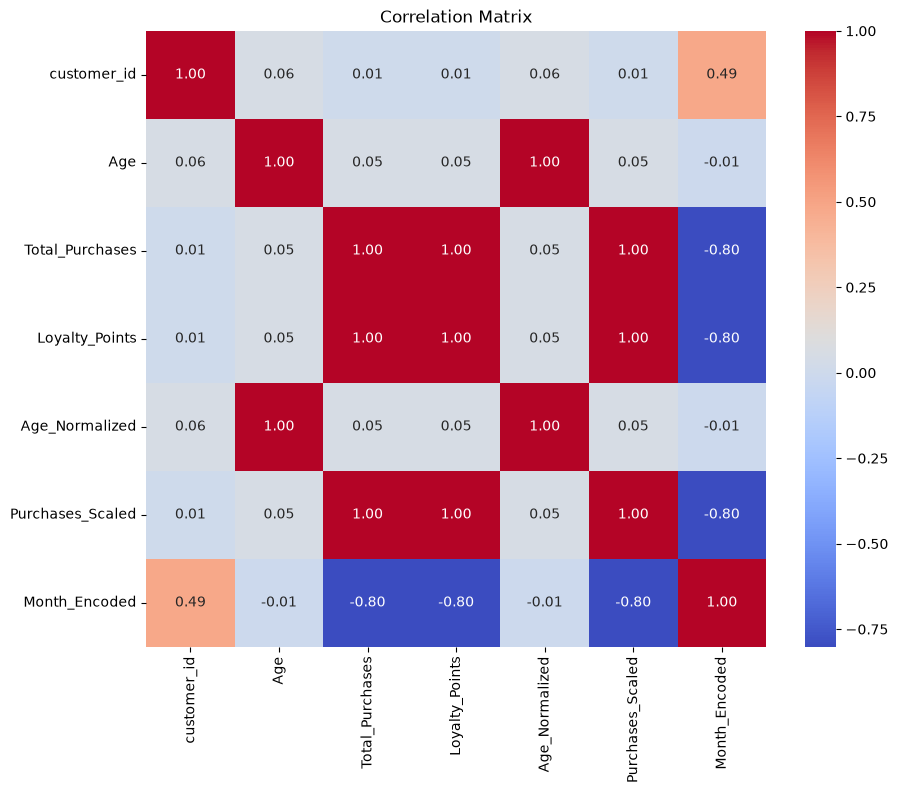

In [12]:
numerical_cols=df.select_dtypes(include=[np.number])
correlation_matrix=numerical_cols.corr()
display(correlation_matrix)

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

****Step 13: Regression Analysis****

,Actual Purchases,Predicted Purchases
1,800,287.109091



--- Model Performance ---
Model Coefficient (Slope): -4.309090909090908
Model Intercept: 446.5454545454545
R-squared Score (Accuracy): nan


C:\Users\VNAV-PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


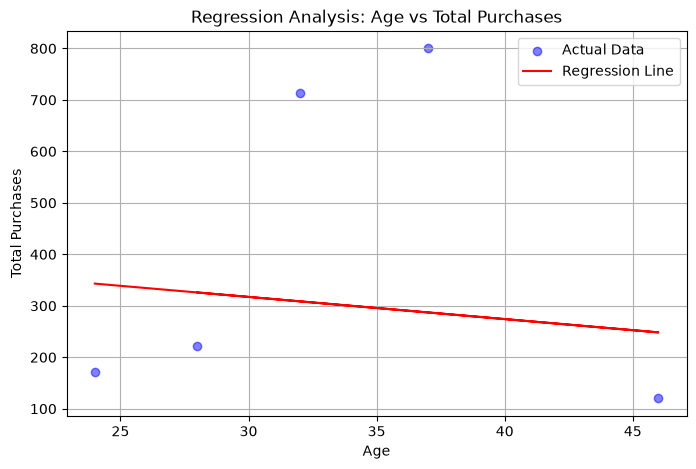

In [13]:
X=df[['Age']]
y=df['Total_Purchases']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

comparison=pd.DataFrame({'Actual Purchases':y_test,'Predicted Purchases':y_pred})
display(comparison.head(10))

print("\n--- Model Performance ---")
print("Model Coefficient (Slope):",model.coef_[0])
print("Model Intercept:",model.intercept_)
print("R-squared Score (Accuracy):",model.score(X_test,y_test))

plt.figure(figsize=(8,5))
plt.scatter(X,y,color='blue',label='Actual Data',alpha=0.5)
plt.plot(X,model.predict(X),color='red',label='Regression Line')
plt.xlabel('Age')
plt.ylabel('Total Purchases')
plt.title('Regression Analysis: Age vs Total Purchases')
plt.legend()
plt.grid(True)
plt.show()